## Task

Use the image `candy.jpg` for this task!

Count the how many:
* colors are on the picture
* what is the proportion of each type of candy on the picture!


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from PIL import Image
import os
import cv2
import scipy.signal
import numpy as np
from sklearn.cluster import KMeans
from skimage import morphology, measure
#plt.rcParams['text.usetex'] = True

# https://pypi.org/project/python-dotenv/
from dotenv import load_dotenv
load_dotenv("env_variables")

True

In [6]:
DATASET_DIR = os.getenv('DATASET_DIR')
image = f"{DATASET_DIR}/Image_Exploration/candy.jpg"

img = cv2.imread(image)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to HSV color space
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

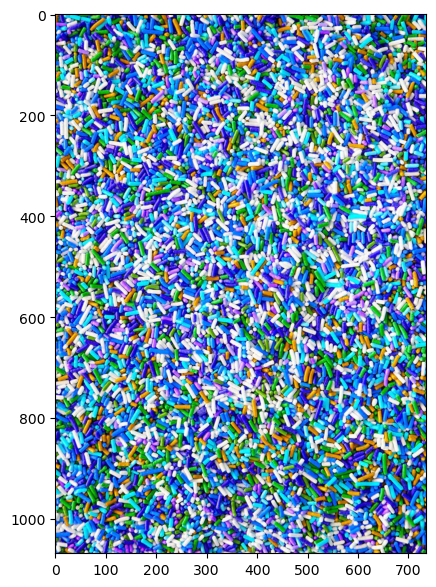

In [14]:
plt.imshow(cv2.imread(image))
plt.show()

In [15]:
axistitlesize = 25
axisticksize = 14
axislabelsize = 22
axislegendsize = 19

In [7]:
color_ranges = {
    "red": [
        (np.array([0, 70, 50]), np.array([10, 255, 255])),
        (np.array([170, 70, 50]), np.array([180, 255, 255]))
    ],
    "green": [(np.array([35, 50, 50]), np.array([85, 255, 255]))],
    "blue": [(np.array([100, 50, 50]), np.array([130, 255, 255]))],
    "yellow": [(np.array([20, 100, 100]), np.array([30, 255, 255]))],
    "orange": [(np.array([10, 100, 100]), np.array([20, 255, 255]))],
    "pink": [(np.array([140, 50, 50]), np.array([170, 255, 255]))],
    "white": [(np.array([0, 0, 200]), np.array([180, 50, 255]))]
}

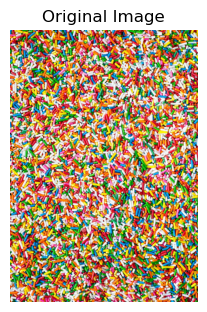

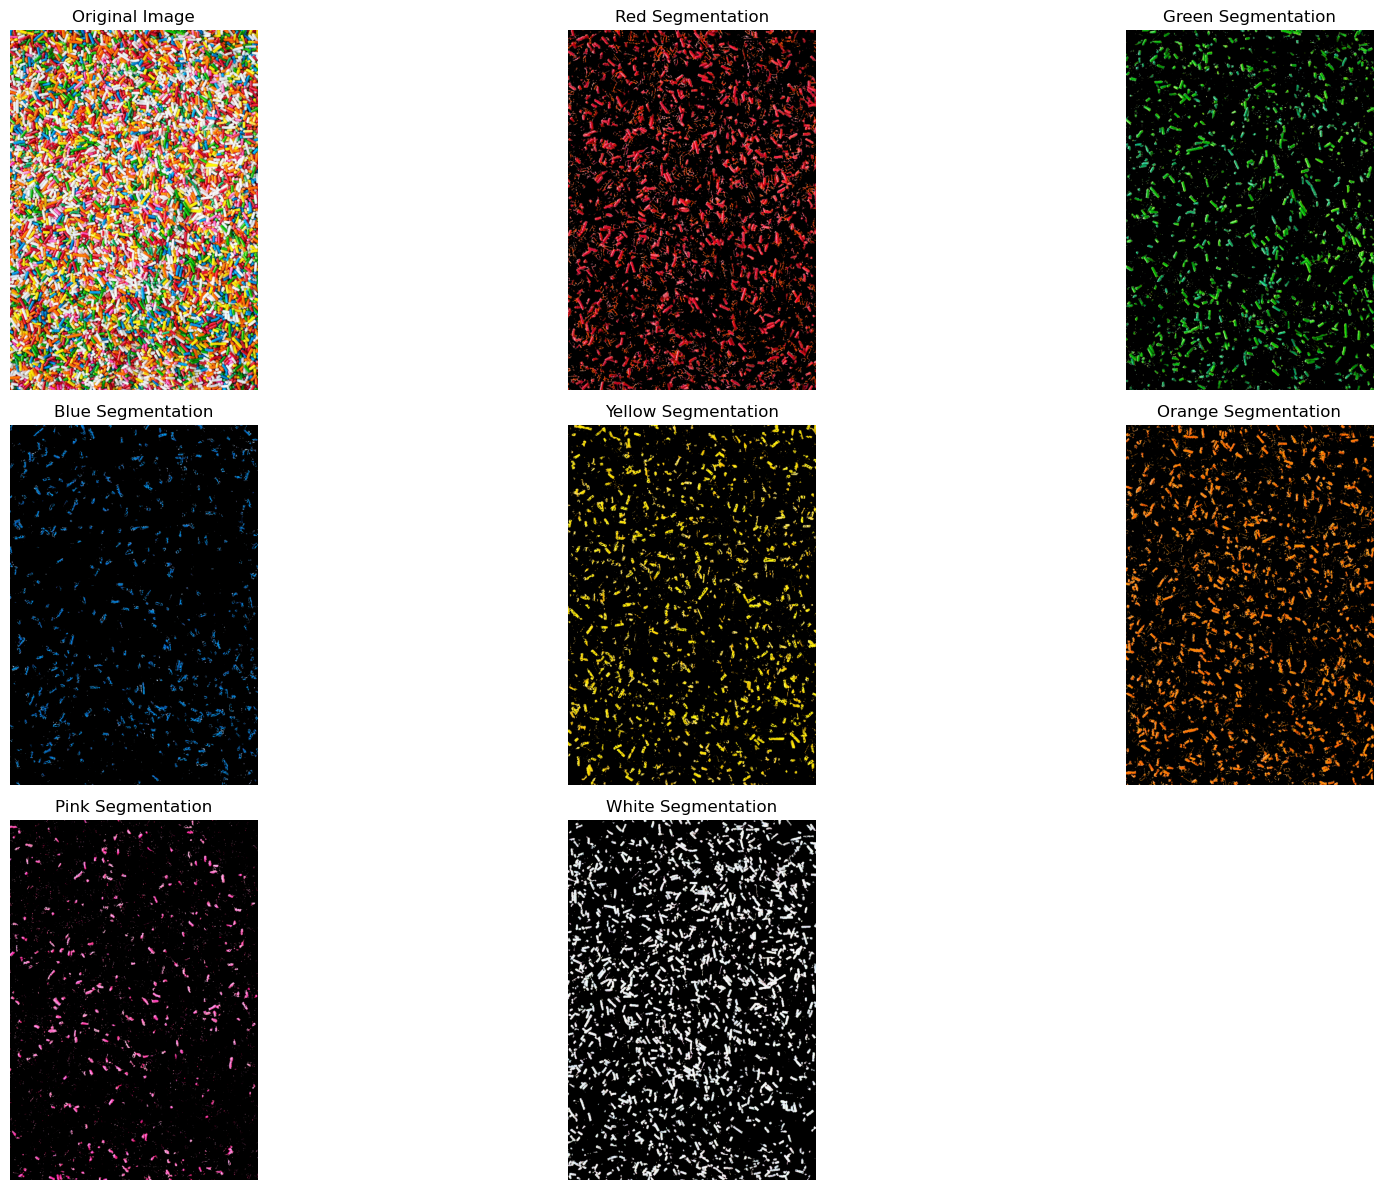

In [8]:
plt.figure(figsize=(18, 12))
plt.subplot(3, 3, 1)
plt.title("Original Image")
plt.imshow(img)
plt.axis("off")

i = 2
for color, ranges in color_ranges.items():
    mask = np.zeros(hsv.shape[:2], dtype=np.uint8)
    for lower, upper in ranges:
        mask |= cv2.inRange(hsv, lower, upper)
    result = cv2.bitwise_and(img, img, mask=mask)
    
    plt.subplot(3, 3, i)
    plt.title(f"{color.capitalize()} Segmentation")
    plt.imshow(result)
    plt.axis("off")
    i += 1

plt.tight_layout()
plt.show()

In [16]:
color_counts = defaultdict(int)
for color, bounds in color_ranges.items():
    mask = np.zeros(hsv.shape[:2], dtype=np.uint8)
    for lower, upper in bounds:
        mask |= cv2.inRange(hsv, lower, upper)
    count = np.sum(mask > 0)
    color_counts[color] = count

# Show the results
print("Pixel counts by HSV mask:")
for color, count in color_counts.items():
    print(f"{color.capitalize():<7}: {count} pixels")

Pixel counts by HSV mask:
Red    : 188012 pixels
Green  : 107359 pixels
Blue   : 38960 pixels
Yellow : 81828 pixels
Orange : 103746 pixels
Pink   : 38069 pixels
White  : 143890 pixels


In [18]:
color_names = ["red", "orange", "yellow", "green", "blue", "pink", "white"]
display_colors = {
    "red": "#ff0000",
    "orange": "#ffa500",
    "yellow": "#ffff00",
    "green": "#00ff00",
    "blue": "#0000ff",
    "pink": "#ff69b4",
    "white": "#dddddd"  # light gray for visibility
}
counts = [color_counts[color] for color in color_names]
bar_colors = [display_colors[color] for color in color_names]

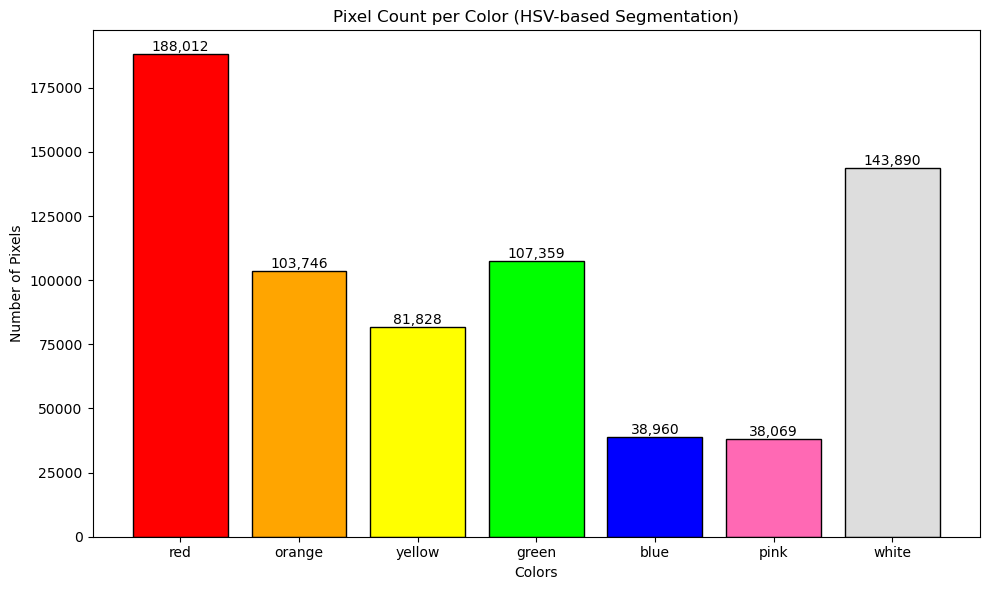

In [20]:
plt.figure(figsize=(10, 6))
bars = plt.bar(color_names, counts, color=bar_colors, edgecolor='black')
plt.xlabel("Colors")
plt.ylabel("Number of Pixels")
plt.title("Pixel Count per Color (HSV-based Segmentation)")
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{count:,}", 
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()